# StarDist retraining — continue from an existing model

Trains a StarDist model through the scikit-ops op, then **continues** training
the same weights rather than starting over, and plots one loss curve across both
runs.

The question it answers: does `initial_model_dir` really pick up where the last
run left off? If it does, the second run's first epoch starts near the first
run's last, instead of jumping back to a from-scratch loss.

Uses the pollen count project, whose patches are already on disk. Kept separate
from `test_stardist_training.ipynb`, which tests the in-process segmenter.


## 1. Setup


In [1]:
import json
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from skimage.io import imread
from skop.ops.segment.stardist2d import stardist2d_custom
from skop.ops.train import train_stardist2d
from skop.runner import Runner

runner = Runner()


In [2]:
project = Path('../tests/test_images/pollen_count').resolve()
patch_dir = project / 'patches' / 'patches_axis_yxc'
model_dir = project / 'models'

# Patch pairs, the way StardistSkopSegmenter builds them: labels are derived
# from the inputs by name, so an extra file in one directory cannot silently
# mispair the set.
inputs = sorted((patch_dir / 'input0').glob('*.tif'))
images = [str(p) for p in inputs]
labels = [str(patch_dir / 'ground_truth0' / p.name) for p in inputs]
assert all(Path(p).exists() for p in labels), 'a patch has no ground truth'

axes = json.loads((patch_dir / 'info.json').read_text())['axes']
print(f'{len(images)} pairs, axes={axes}')


50 pairs, axes=YXC


## 2. Train 10 epochs from scratch


In [ ]:
MODEL = 'retrain_demo'

# Fresh start: remove any model of this name left by an earlier run, so the
# history.csv below is this notebook's and not a previous one's.

shutil.rmtree(model_dir / MODEL, ignore_errors=True)

path = runner.run(
    train_stardist2d,
    images=images,
    labels=labels,
    model_dir=str(model_dir),
    name=MODEL,
    image_axes=axes,
    epochs=10,
    steps_per_epoch=20,
    train_patch_size=128,
    unet_n_depth=3,
    grid_size_xy=2,
    val_size=5,
    on_progress=lambda e: print(e.message),
)
print(path)


None
Reading 50 pairs
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
Training retrain_demo: 45 train, 5 val, 10 epochs
Epoch 1/10 — loss 6.8890, val_loss 7.8218
Epoch 2/10 — loss 6.5685, val_loss 6.8047
Epoch 3/10 — loss 5.2056, val_loss 5.4991
Epoch 4/10 — loss 4.0772, val_loss 4.3530
Epoch 5/10 — loss 3.6058, val_loss 3.9671
Epoch 6/10 — loss 3.7035, val_loss 3.8824
Epoch 7/10 — loss 3.5478, val_loss 3.7578
Epoch 8/10 — loss 3.6358, val_loss 3.7015
Epoch 9/10 — loss 3.3578, val_loss 3.5510
Epoch 10/10 — loss 3.1388, val_loss 3.5238
None
/home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/pollen_count/models/retrain_demo


None
Reading 50 pairs
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
Continuing from /home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/pollen_count/models/retrain_demo
Training retrain_demo: 45 train, 5 val, 10 epochs
Epoch 1/10 — loss 3.8681, val_loss 3.6736
Epoch 2/10 — loss 2.9555, val_loss 2.7991
Epoch 3/10 — loss 2.7281, val_loss 2.5447
Epoch 4/10 — loss 2.6435, val_loss 2.5618
Epoch 5/10 — loss 2.3881, val_loss 2.3908
Epoch 6/10 — loss 2.4614, val_loss 2.2139
Epoch 7/10 — loss 2.0847, val_loss 1.9836
Epoch 8/10 — loss 1.9810, val_loss 2.8492
Epoch 9/10 — loss 2.1158, val_loss 1.9493
Epoch 10/10 — loss 1.7595, val_loss 1.7834
None
None
Reading 50 pairs
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None


## 3. The loss so far

`history.csv` is written into the model directory by the op.


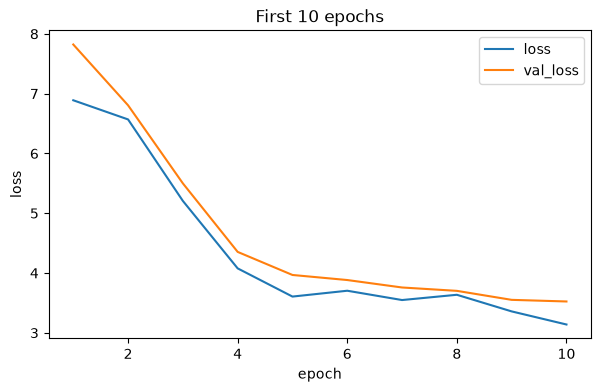

,epoch,loss,val_loss
5,6,3.703486,3.882422
6,7,3.547818,3.757799
7,8,3.635802,3.701474
8,9,3.357823,3.551008
9,10,3.138786,3.523800


In [4]:
def plot_history(model_path, title):
    df = pd.read_csv(Path(model_path) / 'history.csv')
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(df['epoch'], df['loss'], label='loss')
    ax.plot(df['epoch'], df['val_loss'], label='val_loss')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_title(title)
    ax.legend()
    plt.show()
    return df

df = plot_history(path, 'First 10 epochs')
df.tail()


## 4. Continue for 10 more

`initial_model_dir` points at the model just trained, and the destination is the
same name — so this replaces it in place, the "keep training this one" case.
Pointing `name` somewhere else instead would copy first and leave the parent
untouched.


In [6]:
path = runner.run(
    train_stardist2d,
    images=images,
    labels=labels,
    model_dir=str(model_dir),
    name=MODEL,
    initial_model_dir=str(model_dir / MODEL),
    image_axes=axes,
    epochs=10,
    steps_per_epoch=20,
    val_size=5,
    on_progress=lambda e: print(e.message),
)
print(path)


/home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/pollen_count/models/retrain_demo


## 5. One curve across both runs

**What to look for:** the loss at epoch 11 continues from epoch 10 rather than
jumping back up. A jump means the weights were not loaded and this trained from
scratch again.


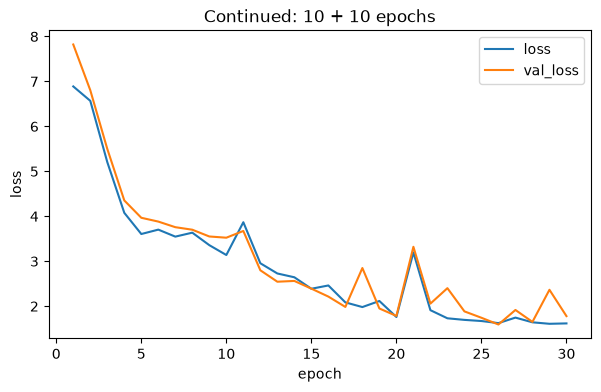

epoch 10: loss 3.1388
epoch 11: loss 3.8681


In [7]:
df = plot_history(path, 'Continued: 10 + 10 epochs')

print(f"epoch 10: loss {df.loc[df.epoch == 10, 'loss'].iat[0]:.4f}")
print(f"epoch 11: loss {df.loc[df.epoch == 11, 'loss'].iat[0]:.4f}")


## 6. Predict with it


In [8]:
# The project's images are PNGs, so read one the way the app would.
image = imread(str(project / '03_three_species.png'))
print(f'{image.shape} {image.dtype}')

pred = runner.run(
    stardist2d_custom,
    image=image,
    model_dir=path,
)
print(f'{pred.max()} objects')


(1024, 956, 3) uint8
65 objects


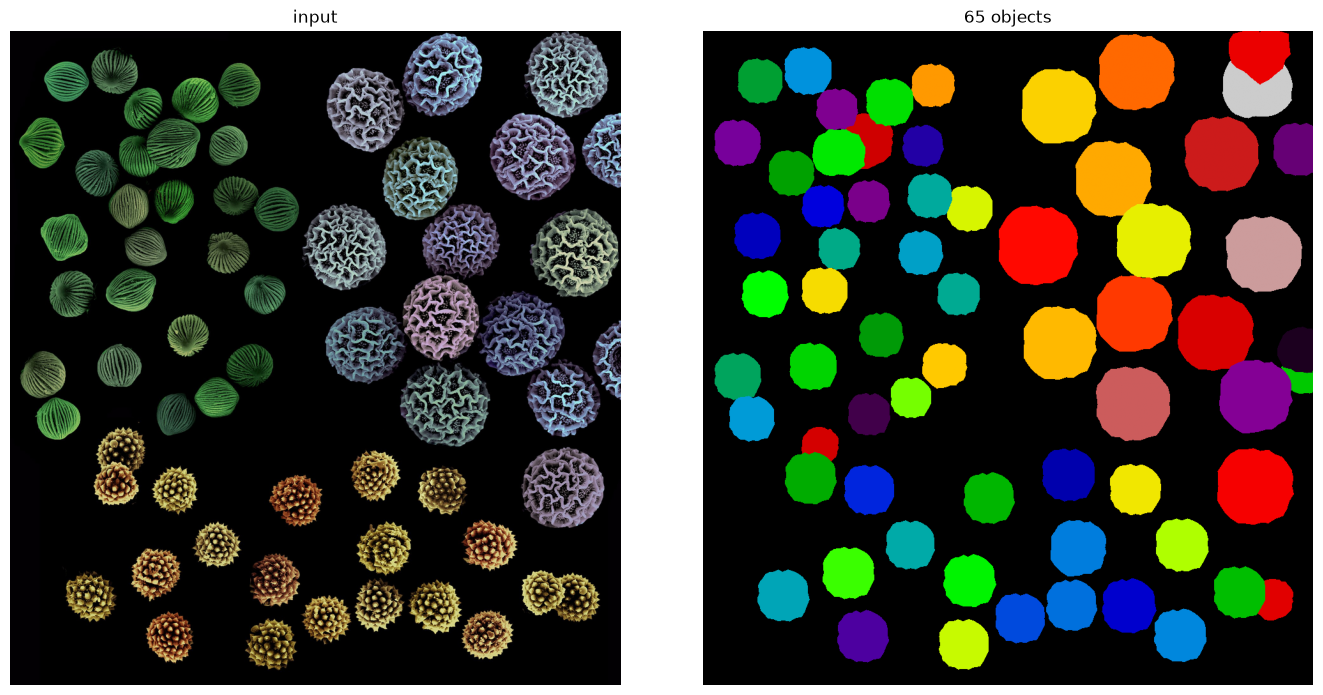

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(image)
ax[0].set_title('input')
ax[1].imshow(pred, cmap='nipy_spectral')
ax[1].set_title(f'{pred.max()} objects')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()


## Notes

Twenty epochs at 20 steps is far too little to segment pollen well — the point
here is the shape of the loss curve, not the quality of the model.

When continuing, the architecture and patch/batch settings come from the saved
model: `unet_n_depth`, `grid_size_xy` and `train_patch_size` are deliberately
left out of the second call, because they are baked into a trained model and
cannot change. `epochs` and `steps_per_epoch` are per-run and still apply.
